# HW_L03_02_pandas_matplotlib

This exercise consists of two parts:

1. **Data preprocessing and preparation using Pandas**  
2. **Data visualization using Seaborn and Matplotlib**

The first part involves data cleaning, preprocessing, and general data preparation tasks performed with Pandas.  
The second part focuses on plotting and creating visualizations required for presenting and analyzing the data.


In [1]:
# basic
import os

# Analysis
import numpy as np
import pandas as pd

# plot
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Preparation and Processing with **Pandas**
 
Mastering dataset merging, working with time series, and creating pivot tables.


### Task 1 : Data Files   

- **orders.csv**: Transaction history, including sales amount (Sales) and profit (Profit).  
- **products.csv**: Details of the sold products (such as category and product name).  
- **customers.csv**: Customer demographic information (such as region and customer type).

In [2]:
# first way
PATH = os.getcwd()
PATH_CUSTOMERS = PATH + "\\customers.csv"
PATH_ORDERS = PATH + "\\orders.csv"
PATH_PRODUCTS = PATH + "\\products.csv"

customers = pd.read_csv(PATH_CUSTOMERS)
orders = pd.read_csv(PATH_ORDERS)
products = pd.read_csv(PATH_PRODUCTS)

#### Second way   
This method helps when you have **many files** and want to load **all of them at once**,  
creating separate DataFrames with **their own names**.

Important note:  
DataFrame names **must not** contain characters like `-`, `.`, spaces, or other invalid symbols.  
Therefore, the file names must be **cleaned first** to produce valid Python variable names.

1. We identify the main directory we are currently in
    
    ```python
    PATH = os.getcwd()
    ```
    This step fixes the read error.  
    If you are using a `cookiecutter project`, the data files are usually located inside the **raw** folder, not in the working directory.  
    Therefore, you cannot read the files directly without specifying their full path.

---

2. We store the names of the files inside the target folder in a list.  
   By applying a condition on the file format, we ensure that only the desired files are included in the list, while other file types are excluded.   
   ```python
   NAME_FILE = [file for file in os.listdir() if file.endswith(".csv")]
   ```

---

3. To organize the information and keep a DataFrame of the files, we convert the list from step 2 into a DataFrame. 

    ```python
    file_info_csv = pd.DataFrame(NAME_FILE, columns=["file_name"])
    ```
   We then add a new column that extracts the DataFrame names from the corresponding file names.
   ```python
   file_info_csv["dataframe_name"] = file_info_csv["file_name"].str.replace(".csv", "")
   ```

---

4. Using a `for` loop and the `globals()` function, we read each file and assign the resulting DataFrame to a variable that matches its own name.
    ```python
    for i in range(len(file_info_csv.index)):
    # make path
    PATH_READ_DATA = PATH + "\\" + file_info_csv["file_name"].iloc[i]
    # read and make df by name with globals()
    globals()[file_info_csv["dataframe_name"].iloc[i]] = pd.read_csv(PATH_READ_DATA)
    ```
    * The `file_name` column contains the file names **including** the `.csv` extension, while the `dataframe_name` column contains the cleaned names that DataFrames should be created with, where the `.csv` string has been removed.
    * The `globals()` function tells Python that the value obtained from the DataFrame is **not a string**, but should be treated as a **variable name**.



In [3]:
# second way
# I use this way always

PATH = os.getcwd()
NAME_FILE = [file for file in os.listdir() if file.endswith(".csv")]

file_info_csv = pd.DataFrame(NAME_FILE, columns=["file_name"])

file_info_csv["dataframe_name"] = file_info_csv["file_name"].str.replace(".csv", "")

for i in range(len(file_info_csv.index)):
    # make path
    PATH_READ_DATA = PATH + "\\" + file_info_csv["file_name"].iloc[i]
    # read and make df by name with globals()
    globals()[file_info_csv["dataframe_name"].iloc[i]] = pd.read_csv(PATH_READ_DATA)


In [4]:
file_info_csv

,file_name,dataframe_name
0,customers.csv,customers
1,orders.csv,orders
2,products.csv,products


In [5]:
globals()[file_info_csv["dataframe_name"][0]].head()

,CustomerID,CustomerName,Segment,Region,State,City
0,DP-13000,Darren Powers,Consumer,Central,Texas,Houston
1,PO-19195,Phillina Ober,Home Office,Central,Illinois,Naperville
2,MB-18085,Mick Brown,Consumer,East,Pennsylvania,Philadelphia
3,ME-17320,Maria Etezadi,Home Office,South,Kentucky,Henderson
4,JO-15145,Jack O'Briant,Corporate,South,Georgia,Athens


In [6]:
customers.head()

,CustomerID,CustomerName,Segment,Region,State,City
0,DP-13000,Darren Powers,Consumer,Central,Texas,Houston
1,PO-19195,Phillina Ober,Home Office,Central,Illinois,Naperville
2,MB-18085,Mick Brown,Consumer,East,Pennsylvania,Philadelphia
3,ME-17320,Maria Etezadi,Home Office,South,Kentucky,Henderson
4,JO-15145,Jack O'Briant,Corporate,South,Georgia,Athens


#### customers information

In [7]:
print(f"shape of customers dataframe: {customers.shape}")
print(f"Count null value of customers dataframe: \n{customers.isnull().sum()}")

shape of customers dataframe: (793, 6)
Count null value of customers dataframe: 
CustomerID      0
CustomerName    0
Segment         0
Region          0
State           0
City            0
dtype: int64


In [8]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   CustomerID    793 non-null    str  
 1   CustomerName  793 non-null    str  
 2   Segment       793 non-null    str  
 3   Region        793 non-null    str  
 4   State         793 non-null    str  
 5   City          793 non-null    str  
dtypes: str(6)
memory usage: 37.3 KB


In [9]:
customers.describe()


,CustomerID,CustomerName,Segment,Region,State,City
count,793,793,793,793,793,793
unique,793,793,3,4,43,247
top,DP-13000,Darren Powers,Consumer,West,California,Los Angeles
freq,1,1,409,252,156,59


#### orders information

In [10]:
orders.head()

,OrderID,OrderDate,CustomerID,ProductID,Sales,Quantity,Discount,Profit
0,CA-2019-103800,2019-01-03,DP-13000,OFF-PA-10000174,16.448,2,0.2,5.5512
1,CA-2019-112326,2019-01-04,PO-19195,OFF-LA-10003223,11.784,3,0.2,4.2717
2,CA-2019-112326,2019-01-04,PO-19195,OFF-ST-10002743,272.736,3,0.2,-64.7748
3,CA-2019-112326,2019-01-04,PO-19195,OFF-BI-10004094,3.540,2,0.8,-5.4870
4,CA-2019-141817,2019-01-05,MB-18085,OFF-AR-10003478,19.536,3,0.2,4.8840


In [11]:
print(f"shape of customers dataframe: {orders.shape}")
print(f"Count null value of customers dataframe: \n{orders.isnull().sum()}")

shape of customers dataframe: (9994, 8)
Count null value of customers dataframe: 
OrderID       0
OrderDate     0
CustomerID    0
ProductID     0
Sales         0
Quantity      0
Discount      0
Profit        0
dtype: int64


In [12]:
orders.describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


#### products inormation

In [13]:
products.head()

,ProductID,Category,SubCategory,ProductName
0,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form..."
1,OFF-LA-10003223,Office Supplies,Labels,Avery 508
2,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving
3,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs
4,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...


In [14]:
print(f"shape of customers dataframe: {orders.shape}")
print(f"Count null value of customers dataframe: \n{orders.isnull().sum()}")

shape of customers dataframe: (9994, 8)
Count null value of customers dataframe: 
OrderID       0
OrderDate     0
CustomerID    0
ProductID     0
Sales         0
Quantity      0
Discount      0
Profit        0
dtype: int64


In [15]:
products.describe()

,ProductID,Category,SubCategory,ProductName
count,1862,1862,1862,1862
unique,1862,3,17,1818
top,OFF-PA-10000174,Office Supplies,Paper,Staples
freq,1,1083,276,10


### Task 2 : Merge Instructions (Translated for Jupyter Notebook)

The `orders` table contains only ID fields and no detailed information.  
We must add the related information to it.

**Step 1:**  
Merge the `orders` DataFrame with the `products` DataFrame based on the `ProductID` column.

**Step 2:**  
Merge the result with the `customers` DataFrame based on the `CustomerID` column.

**Step 3:**  
Store the final merged result in a variable named `df_master`.  
Then check its shape to ensure no data was lost.


In [16]:
# first way
df_master = (orders.merge(products,
                          left_on="ProductID",
                          right_on="ProductID",
                          how="left").merge(customers,
                                            left_on="CustomerID",
                                            right_on="CustomerID",
                                            how="left"))

In [17]:
df_master.head(3)

,OrderID,OrderDate,CustomerID,ProductID,Sales,Quantity,Discount,Profit,Category,SubCategory,ProductName,CustomerName,Segment,Region,State,City
0,CA-2019-103800,2019-01-03,DP-13000,OFF-PA-10000174,16.448,2,0.2,5.5512,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Darren Powers,Consumer,Central,Texas,Houston
1,CA-2019-112326,2019-01-04,PO-19195,OFF-LA-10003223,11.784,3,0.2,4.2717,Office Supplies,Labels,Avery 508,Phillina Ober,Home Office,Central,Illinois,Naperville
2,CA-2019-112326,2019-01-04,PO-19195,OFF-ST-10002743,272.736,3,0.2,-64.7748,Office Supplies,Storage,SAFCO Boltless Steel Shelving,Phillina Ober,Home Office,Central,Illinois,Naperville


In [18]:
orders.shape, df_master.shape

# orders   = 8 columns
# products = 4 columns
# customers= 6 columns
# df_master = 8 + 4 + 6 -(2 columns for merge) = 16

((9994, 8), (9994, 16))

In [19]:
orders.shape[0] == df_master.shape[0]

True

In [20]:
# second way
merge_orders_products = pd.merge(orders,
                                 products,
                                 left_on="ProductID",
                                 right_on= "ProductID",
                                 how="left")

df_master = pd.merge(merge_orders_products,
                     customers,
                     left_on="CustomerID",
                     right_on="CustomerID",
                     how="left")
df_master.head(2)

,OrderID,OrderDate,CustomerID,ProductID,Sales,Quantity,Discount,Profit,Category,SubCategory,ProductName,CustomerName,Segment,Region,State,City
0,CA-2019-103800,2019-01-03,DP-13000,OFF-PA-10000174,16.448,2,0.2,5.5512,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Darren Powers,Consumer,Central,Texas,Houston
1,CA-2019-112326,2019-01-04,PO-19195,OFF-LA-10003223,11.784,3,0.2,4.2717,Office Supplies,Labels,Avery 508,Phillina Ober,Home Office,Central,Illinois,Naperville


In [21]:
orders.shape, df_master.shape

((9994, 8), (9994, 16))

In [22]:
orders.shape[0] == df_master.shape[0]

True

### Task 3: Feature Engineering

1. Unit Price  
In the dataset, the `Sales` column represents the total revenue of the transaction.  
Create a new column named `UnitPrice` where:

    UnitPrice = Sales / Quantity

2. Profit Margin  
To calculate sales efficiency, create a new column named `Margin` where:

    Margin = Profit / Sales


In [23]:
df_master.head(2)

,OrderID,OrderDate,CustomerID,ProductID,Sales,Quantity,Discount,Profit,Category,SubCategory,ProductName,CustomerName,Segment,Region,State,City
0,CA-2019-103800,2019-01-03,DP-13000,OFF-PA-10000174,16.448,2,0.2,5.5512,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Darren Powers,Consumer,Central,Texas,Houston
1,CA-2019-112326,2019-01-04,PO-19195,OFF-LA-10003223,11.784,3,0.2,4.2717,Office Supplies,Labels,Avery 508,Phillina Ober,Home Office,Central,Illinois,Naperville


In [24]:
df_master["UnitPrice"] = df_master["Sales"] / df_master["Quantity"]
df_master["Margin"] = df_master["Profit"] / df_master["Sales"]


In [25]:
df_master[["Sales", "Quantity", "Profit", "UnitPrice", "Margin"]]

,Sales,Quantity,Profit,UnitPrice,Margin
0,16.448,2,5.5512,8.224,0.3375
1,11.784,3,4.2717,3.928,0.3625
2,272.736,3,-64.7748,90.912,-0.2375
3,3.540,2,-5.4870,1.770,-1.5500
4,19.536,3,4.8840,6.512,0.2500
...,...,...,...,...,...
9989,3.024,3,-0.6048,1.008,-0.2000
9990,52.776,3,19.7910,17.592,0.3750
9991,90.930,7,2.7279,12.990,0.0300
9992,13.904,2,4.5188,6.952,0.3250


### Task 4 : Time Series Analysis

1. Convert `OrderDate` to datetime
Convert the `OrderDate` column into proper `datetime` format.

2. Set `OrderDate` as index
Assign the `OrderDate` column as the **index** of the `df_master` DataFrame.

3. Monthly Aggregation Using `resample("ME")`
Use the `resample("ME")` method to group data **monthly** and compute:

    - Total `Sales` per month  
    - Total `Profit` per month  

4. Question
Identify **exactly which month (year–month)** had the **highest total Sales**.


In [26]:
# Convert OrderDate to datetime
df_master["OrderDate"] = pd.to_datetime(df_master["OrderDate"])

In [27]:
df_master["OrderDate"][1] - df_master["OrderDate"][0]

Timedelta('1 days 00:00:00')

In [28]:
# Set OrderDate as inde
df_master.set_index("OrderDate", inplace=True) 
# inplace=True : change in main data

In [29]:
df_master.head()

,OrderID,CustomerID,ProductID,Sales,Quantity,Discount,Profit,Category,SubCategory,ProductName,CustomerName,Segment,Region,State,City,UnitPrice,Margin
OrderDate,,,,,,,,,,,,,,,,,
2019-01-03,CA-2019-103800,DP-13000,OFF-PA-10000174,16.448,2,0.2,5.5512,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Darren Powers,Consumer,Central,Texas,Houston,8.224,0.3375
2019-01-04,CA-2019-112326,PO-19195,OFF-LA-10003223,11.784,3,0.2,4.2717,Office Supplies,Labels,Avery 508,Phillina Ober,Home Office,Central,Illinois,Naperville,3.928,0.3625
2019-01-04,CA-2019-112326,PO-19195,OFF-ST-10002743,272.736,3,0.2,-64.7748,Office Supplies,Storage,SAFCO Boltless Steel Shelving,Phillina Ober,Home Office,Central,Illinois,Naperville,90.912,-0.2375
2019-01-04,CA-2019-112326,PO-19195,OFF-BI-10004094,3.540,2,0.8,-5.4870,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,Phillina Ober,Home Office,Central,Illinois,Naperville,1.770,-1.5500
2019-01-05,CA-2019-141817,MB-18085,OFF-AR-10003478,19.536,3,0.2,4.8840,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Mick Brown,Consumer,East,Pennsylvania,Philadelphia,6.512,0.2500


In [30]:
# Monthly Aggregation Using resample("ME")
# first way
df_master["Sales"].resample("ME").sum()

OrderDate
2019-01-31     14236.8950
2019-02-28      4519.8920
2019-03-31     55691.0090
2019-04-30     28295.3450
2019-05-31     23648.2870
2019-06-30     34595.1276
2019-07-31     33946.3930
2019-08-31     27909.4685
2019-09-30     81777.3508
2019-10-31     31453.3930
2019-11-30     78628.7167
2019-12-31     69545.6205
2020-01-31     18174.0756
2020-02-29     13593.5854
2020-03-31     37084.0776
2020-04-30     34646.1485
2020-05-31     30514.9445
2020-06-30     23963.0940
2020-07-31     29777.0210
2020-08-31     38254.2002
2020-09-30     63386.7680
2020-10-31     33352.6155
2020-11-30     79997.0515
2020-12-31     67788.9272
2021-01-31     18704.4610
2021-02-28     22816.8450
2021-03-31     51715.8750
2021-04-30     38750.0390
2021-05-31     56987.7280
2021-06-30     40344.5340
2021-07-31     39261.9630
2021-08-31     31115.3743
2021-09-30     73410.0249
2021-10-31     59687.7450
2021-11-30     79411.9658
2021-12-31     96999.0430
2022-01-31     43971.3740
2022-02-28     20301.1334
20

In [31]:
# Monthly Aggregation Using resample("ME")
df_master["Profit"].resample("ME").sum()

OrderDate
2019-01-31     2450.1907
2019-02-28      862.3084
2019-03-31      498.7299
2019-04-30     3488.8352
2019-05-31     2738.7096
2019-06-30     4976.5244
2019-07-31     -841.4826
2019-08-31     5318.1050
2019-09-30     8328.0994
2019-10-31     3448.2573
2019-11-30     9292.1269
2019-12-31     8983.5699
2020-01-31    -3281.0070
2020-02-29     2826.5690
2020-03-31     9719.3796
2020-04-30     4253.7196
2020-05-31     4902.1242
2020-06-30     3035.0786
2020-07-31     3116.1375
2020-08-31     6280.2620
2020-09-30     7626.9201
2020-10-31     3569.7223
2020-11-30    12505.8409
2020-12-31     7063.8569
2021-01-31     2888.0395
2021-02-28     4941.3633
2021-03-31     3611.9680
2021-04-30     2977.8149
2021-05-31     8662.1464
2021-06-30     4750.3781
2021-07-31     4432.8779
2021-08-31     2062.0693
2021-09-30     9328.6576
2021-10-31    16243.1425
2021-11-30     4011.4075
2021-12-31    17885.3093
2022-01-31     7140.4391
2022-02-28     1613.8720
2022-03-31    14751.8915
2022-04-30     

In [32]:
# second way
# same as groupby
df_master.resample("ME").agg({"Sales": "sum","Profit": "sum"})

,Sales,Profit
OrderDate,,
2019-01-31,14236.8950,2450.1907
2019-02-28,4519.8920,862.3084
2019-03-31,55691.0090,498.7299
2019-04-30,28295.3450,3488.8352
2019-05-31,23648.2870,2738.7096
2019-06-30,34595.1276,4976.5244
2019-07-31,33946.3930,-841.4826
2019-08-31,27909.4685,5318.1050
2019-09-30,81777.3508,8328.0994


In [33]:
# Identify exactly which month (year–month) had the highest total Sales

# first way
print("top year–month is :")
(df_master.resample("ME").agg({"Sales": "sum","Profit": "sum"}).
 sort_values(by=["Sales", "Profit"], ascending=False)).index[0].to_period("M")



# make df by resample and month by Sales and Profit (agg= sum)
# sort value first Sales and second Profit
# find first index
# show year and mont by to_period("M")

top year–month is :


Period('2022-11', 'M')

In [34]:
# 3 top sales
# index[0:3] selection
print("top 3 year–month is :")
(df_master.resample("ME").agg({"Sales": "sum","Profit": "sum"}).
 sort_values(by=["Sales", "Profit"], ascending=False)).index[0:3].to_period("M")



top 3 year–month is :


PeriodIndex(['2022-11', '2021-12', '2022-09'], dtype='period[M]', name='OrderDate')

### Task 5 : Customer Segmentation (Pivot Tables)

### Create a Pivot Table to analyze profitability based on customer type.

- **Index:** `Segment` (e.g., Consumer, Corporate)
- **Columns:** `Category` (e.g., Furniture, Technology)
- **Values:** `Profit`
- **Aggfunc:** `sum`

### Question
Which customer **Segment** generated the **highest total Profit** in the **Technology** category?


In [36]:
df_master.head(2)

,OrderID,CustomerID,ProductID,Sales,Quantity,Discount,Profit,Category,SubCategory,ProductName,CustomerName,Segment,Region,State,City,UnitPrice,Margin
OrderDate,,,,,,,,,,,,,,,,,
2019-01-03,CA-2019-103800,DP-13000,OFF-PA-10000174,16.448,2,0.2,5.5512,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Darren Powers,Consumer,Central,Texas,Houston,8.224,0.3375
2019-01-04,CA-2019-112326,PO-19195,OFF-LA-10003223,11.784,3,0.2,4.2717,Office Supplies,Labels,Avery 508,Phillina Ober,Home Office,Central,Illinois,Naperville,3.928,0.3625


In [37]:
(pd.pivot_table(data= df_master,
               index="Segment",
               columns="Category",
               values= "Profit",
               aggfunc="sum").
               sort_values(by="Technology",
                           ascending=False))

Category,Furniture,Office Supplies,Technology
Segment,,,
Consumer,6991.0786,56330.3210,70797.8096
Corporate,7584.8158,40227.3202,44166.9980
Home Office,3875.3784,25933.1596,30490.1405


In [38]:
print("max Technology by Segmentis :")
(pd.pivot_table(data= df_master,
               index="Segment",
               columns="Category",
               values= "Profit",
               aggfunc="sum").
               sort_values(by="Technology",
                           ascending=False)).index[0]

max Technology by Segmentis :


'Consumer'

## Part 2 : Data Visualization with Matplotlib and Seaborn

Discover patterns and trends in the dataset using different types of plots.

Use the `df_master` DataFrame that you created in the previous section.


In [39]:
df_master.head(2)

,OrderID,CustomerID,ProductID,Sales,Quantity,Discount,Profit,Category,SubCategory,ProductName,CustomerName,Segment,Region,State,City,UnitPrice,Margin
OrderDate,,,,,,,,,,,,,,,,,
2019-01-03,CA-2019-103800,DP-13000,OFF-PA-10000174,16.448,2,0.2,5.5512,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Darren Powers,Consumer,Central,Texas,Houston,8.224,0.3375
2019-01-04,CA-2019-112326,PO-19195,OFF-LA-10003223,11.784,3,0.2,4.2717,Office Supplies,Labels,Avery 508,Phillina Ober,Home Office,Central,Illinois,Naperville,3.928,0.3625


### task 1:  Sales Trend vs. Profit Trend

1. Step 1 — Monthly Resampling
    Perform a new monthly resampling on the `df_master` dataset to compute:

    - Total monthly **Sales**
    - Total monthly **Profit**

2. Step 2 — Plotting with `plt.plot()`
    - Draw a line plot using `plt.plot()`.
    - Plot **Sales** in **blue**.
    - Plot **Profit** in **green** on the **same chart**.

3. Step 3 — Labels and Title
    - Add axis labels.
    - Add a title such as: `Monthly Sales vs Profit`.

4. Step 4 — Question
    Do Sales and Profit always move together?  
    Are there months where **Sales are high but Profit is low**, or the opposite?


In [40]:
# Step 1 — Monthly Resampling
df_master.head()

,OrderID,CustomerID,ProductID,Sales,Quantity,Discount,Profit,Category,SubCategory,ProductName,CustomerName,Segment,Region,State,City,UnitPrice,Margin
OrderDate,,,,,,,,,,,,,,,,,
2019-01-03,CA-2019-103800,DP-13000,OFF-PA-10000174,16.448,2,0.2,5.5512,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Darren Powers,Consumer,Central,Texas,Houston,8.224,0.3375
2019-01-04,CA-2019-112326,PO-19195,OFF-LA-10003223,11.784,3,0.2,4.2717,Office Supplies,Labels,Avery 508,Phillina Ober,Home Office,Central,Illinois,Naperville,3.928,0.3625
2019-01-04,CA-2019-112326,PO-19195,OFF-ST-10002743,272.736,3,0.2,-64.7748,Office Supplies,Storage,SAFCO Boltless Steel Shelving,Phillina Ober,Home Office,Central,Illinois,Naperville,90.912,-0.2375
2019-01-04,CA-2019-112326,PO-19195,OFF-BI-10004094,3.540,2,0.8,-5.4870,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,Phillina Ober,Home Office,Central,Illinois,Naperville,1.770,-1.5500
2019-01-05,CA-2019-141817,MB-18085,OFF-AR-10003478,19.536,3,0.2,4.8840,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Mick Brown,Consumer,East,Pennsylvania,Philadelphia,6.512,0.2500


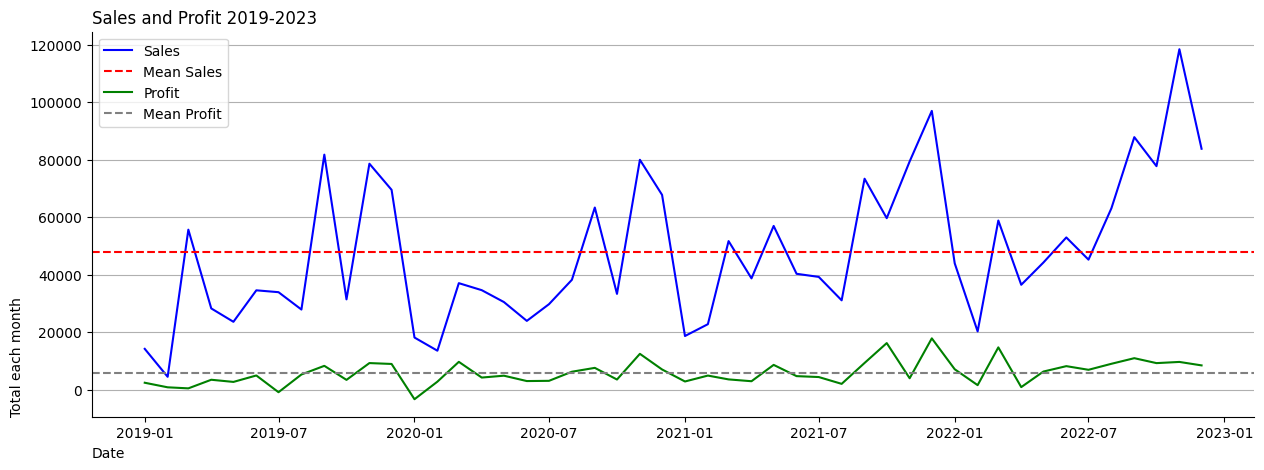

In [57]:
monthly_sales_profit = df_master.resample("ME").agg({"Sales": "sum","Profit": "sum"})

plt.figure(figsize=(15,5))
# x_axis is datetime by to_period("M")
# monthly_sales_profit.index.to_period("M")-> type is 'period[M]'
# change 'period[M]' to 'datetime64[us]'
x_axis = monthly_sales_profit.index.to_period("M").to_timestamp()

plt.plot(x_axis,
         monthly_sales_profit["Sales"],
         color="b",
         linestyle="-",
         label="Sales")
# mean sales
plt.axhline(y=monthly_sales_profit["Sales"].mean(),
            color="r",
            linestyle="--",
            label="Mean Sales")

plt.plot(x_axis,
         monthly_sales_profit["Profit"],
         color="g",
         linestyle="-",
         label="Profit")
#mean profit
plt.axhline(y=monthly_sales_profit["Profit"].mean(),
            color="gray",
            linestyle="--",
            label="Mean Profit")
# ---------plot setting--------
# Use http://matplotlib.org/stable/gallery/showcase/anatomy.html

# label and location
plt.xlabel("Date", loc="left")
plt.ylabel("Total each month", loc="bottom")
plt.title("Sales and Profit 2019-2023", loc="left")

# grid line
plt.grid(axis="y")

# delete line up and right plot
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# legend and location
plt.legend(loc="upper left")
plt.show()